# ============================================================
# Anexo : Primera Exposición Académica Programada
# Mini-experimento reproducible de recuperación imagen-texto
# con imágenes sintéticas inspiradas en textiles andinos
# usando OpenCLIP
# Elaborado por: Henry Sanchez Alvarado
# MCC225A – IA Generativa y Aprendizaje Multimodal
# Maestría en Ciencias de la Computación – 2026-1
# ============================================================


Mini-experimento reproducible de recuperación multimodal imagen-texto.

Objetivo:
1. Generar un conjunto sintético de 10 imágenes inspiradas en rasgos visuales
   frecuentes de textiles andinos.
2. Asociar cada imagen con una descripción textual controlada.
3. Usar OpenCLIP para obtener embeddings de imágenes y textos.
4. Calcular similitud imagen-texto y evaluar recuperación Top-K.

Importante:
- Este experimento NO busca reemplazar el análisis de textiles reales.
- Las imágenes son sintéticas y controladas, diseñadas para reducir ruido visual
  y facilitar la reproducibilidad.
- El objetivo es demostrar una línea base de alineamiento multimodal.


#Importaciones, semilla y entorno

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from sklearn.metrics.pairwise import cosine_similarity

import torch
import open_clip

# -------------------------------
# Reproducibilidad
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Dispositivo detectado: {DEVICE}")
print(f"Semilla fijada en: {SEED}")

d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo detectado: cpu
Semilla fijada en: 42


#Estructura de carpetas

In [2]:
from pathlib import Path

# Detectar raíz del proyecto
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_DIR / "images"
TEXTS_DIR = DATA_DIR / "texts"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

CANDIDATE_TEXTS_PATH = TEXTS_DIR / "candidate_texts.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMAGES_DIR:", IMAGES_DIR)
print("CANDIDATE_TEXTS_PATH:", CANDIDATE_TEXTS_PATH)

PROJECT_ROOT: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos
IMAGES_DIR: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\data\images
CANDIDATE_TEXTS_PATH: d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\data\texts\candidate_texts.csv


In [3]:
texts_df = pd.read_csv(CANDIDATE_TEXTS_PATH)
texts_df

,id,texto,tipo,imagen_correcta
0,TXT_01,Textil andino sintético con franjas horizontal...,correcto,IMG_01
1,TXT_02,Textil andino sintético con franjas verticales...,correcto,IMG_02
2,TXT_03,Textil andino sintético con motivo geométrico ...,correcto,IMG_03
3,TXT_04,Textil andino sintético con rombos centrales r...,correcto,IMG_04
4,TXT_05,Textil andino sintético con composición modula...,correcto,IMG_05
5,TXT_06,Textil andino sintético con bandas decorativas...,correcto,IMG_06
6,TXT_07,Textil andino sintético con bloques cuadrados ...,correcto,IMG_07
7,TXT_08,Textil andino sintético con composición bilate...,correcto,IMG_08
8,TXT_09,Textil andino sintético de alta densidad geomé...,correcto,IMG_09
9,TXT_10,Textil andino sintético con motivo geométrico ...,correcto,IMG_10


#Diseño experimental y paleta cromática

In [ ]:
# ============================================================
# Paleta cromática
# Base: inspirada en fibras naturales de llama, alpaca y vicuña
# Acentos: sutiles y de uso moderado
# ============================================================

PALETTE = {
    "C1": (242, 236, 226),  # blanco hueso
    "C2": (222, 204, 176),  # beige arena
    "C3": (191, 156, 106),  # ocre suave
    "C4": (140, 101, 66),   # marrón medio
    "C5": (95, 64, 42),     # marrón oscuro
    "C6": (160, 156, 148),  # gris piedra
    "C7": (92, 92, 88),     # gris carbón
    "C8": (35, 35, 35),     # negro profundo

    # Acentos sutiles
    "A1": (146, 72, 72),    # rojo cochinilla apagado
    "A2": (86, 106, 130),   # azul añil tenue
    "A3": (102, 122, 92),   # verde musgo suave
}

# Especificación resumida del dataset
dataset_specs = [
    {"id": "T01", "nombre": "Franjas horizontales simétricas", "desc": "Textil andino sintético con franjas horizontales repetidas y organización simétrica del color."},
    {"id": "T02", "nombre": "Franjas verticales alternadas", "desc": "Textil andino sintético con franjas verticales alternadas y estructura visual ordenada."},
    {"id": "T03", "nombre": "Motivo escalonado", "desc": "Textil andino sintético con motivo geométrico escalonado repetido en composición regular."},
    {"id": "T04", "nombre": "Rombos centrales", "desc": "Textil andino sintético con rombos centrales repetidos y simetría axial."},
    {"id": "T05", "nombre": "Cuadrícula modular tipo tocapu", "desc": "Textil andino sintético con composición modular en cuadrícula, inspirada en patrones tipo tocapu."},
    {"id": "T06", "nombre": "Bandas con motivos pequeños", "desc": "Textil andino sintético con bandas decorativas y pequeños motivos geométricos repetidos."},
    {"id": "T07", "nombre": "Composición tipo tablero", "desc": "Textil andino sintético con bloques cuadrados alternados en composición regular tipo tablero."},
    {"id": "T08", "nombre": "Simetría bilateral", "desc": "Textil andino sintético con composición bilateral y equilibrio visual entre ambos lados."},
    {"id": "T09", "nombre": "Alta densidad geométrica", "desc": "Textil andino sintético de alta densidad geométrica con repetición de figuras pequeñas."},
    {"id": "T10", "nombre": "Motivo central con marco", "desc": "Textil andino sintético con motivo geométrico central enmarcado por bandas decorativas."},
]

df_specs = pd.DataFrame(dataset_specs)
df_specs

,id,nombre,desc
0,T01,Franjas horizontales simétricas,Textil andino sintético con franjas horizontal...
1,T02,Franjas verticales alternadas,Textil andino sintético con franjas verticales...
2,T03,Motivo escalonado,Textil andino sintético con motivo geométrico ...
3,T04,Rombos centrales,Textil andino sintético con rombos centrales r...
4,T05,Cuadrícula modular tipo tocapu,Textil andino sintético con composición modula...
5,T06,Bandas con motivos pequeños,Textil andino sintético con bandas decorativas...
6,T07,Composición tipo tablero,Textil andino sintético con bloques cuadrados ...
7,T08,Simetría bilateral,Textil andino sintético con composición bilate...
8,T09,Alta densidad geométrica,Textil andino sintético de alta densidad geomé...
9,T10,Motivo central con marco,Textil andino sintético con motivo geométrico ...


#Funciones auxiliares para dibujo

In [ ]:
# ============================================================
# Funciones auxiliares de dibujo
# ============================================================

SIZE = 512

def new_canvas(bg="C1"):
    img = Image.new("RGB", (SIZE, SIZE), PALETTE[bg])
    return img, ImageDraw.Draw(img)

def draw_diamond(draw, center, radius, fill, outline=None, width=2):
    cx, cy = center
    points = [(cx, cy - radius), (cx + radius, cy), (cx, cy + radius), (cx - radius, cy)]
    draw.polygon(points, fill=PALETTE[fill], outline=PALETTE[outline] if outline else None)
    if outline:
        draw.line(points + [points[0]], fill=PALETTE[outline], width=width)

def draw_step_motif(draw, x, y, step, levels, fill):
    # Dibuja un motivo escalonado simple
    for i in range(levels):
        draw.rectangle(
            [x + i*step, y - (i+1)*step, x + (i+1)*step, y - i*step],
            fill=PALETTE[fill]
        )

def draw_small_cross(draw, x, y, size, fill):
    half = size // 2
    draw.rectangle([x-half, y-1, x+half, y+1], fill=PALETTE[fill])
    draw.rectangle([x-1, y-half, x+1, y+half], fill=PALETTE[fill])

def draw_small_diamond(draw, x, y, r, fill):
    draw_diamond(draw, (x, y), r, fill)

def add_border(draw, margin, color, width=8):
    draw.rectangle([margin, margin, SIZE-margin, SIZE-margin], outline=PALETTE[color], width=width)

#Funciones para generar las 10 imágenes

In [ ]:
# ============================================================
# Generación de cada patrón sintético
# ============================================================

def make_T01():
    img, draw = new_canvas("C1")
    colors = ["C2", "C4", "C6", "C4", "C2", "C2", "C4", "C6", "C4", "C2"]
    stripe_h = SIZE // len(colors)
    for i, c in enumerate(colors):
        y0 = i * stripe_h
        y1 = (i + 1) * stripe_h
        draw.rectangle([0, y0, SIZE, y1], fill=PALETTE[c])
    return img

def make_T02():
    img, draw = new_canvas("C2")
    colors = ["C3", "C5", "C7", "C2", "A2", "C5", "C3", "C7", "C2", "A2"]
    stripe_w = SIZE // len(colors)
    for i, c in enumerate(colors):
        x0 = i * stripe_w
        x1 = (i + 1) * stripe_w
        draw.rectangle([x0, 0, x1, SIZE], fill=PALETTE[c])
    return img

def make_T03():
    img, draw = new_canvas("C1")
    # bandas horizontales base
    for y in [80, 220, 360]:
        draw.rectangle([40, y, SIZE-40, y+60], fill=PALETTE["C3"])
        for x in range(70, SIZE-100, 90):
            draw_step_motif(draw, x, y+55, step=12, levels=4, fill="C8")
            # acento sutil
            draw.rectangle([x+20, y+15, x+32, y+27], fill=PALETTE["A1"])
    return img

def make_T04():
    img, draw = new_canvas("C1")
    add_border(draw, 30, "C2", 10)
    centers_y = [100, 190, 280, 370]
    for cy in centers_y:
        draw_diamond(draw, (SIZE//2, cy), 45, fill="C5", outline="C8")
        draw_diamond(draw, (SIZE//2, cy), 18, fill="A1")
    return img

def make_T05():
    img, draw = new_canvas("C2")
    rows, cols = 4, 4
    cell = SIZE // 4
    base_colors = ["C3", "C4", "C6", "C8"]
    for r in range(rows):
        for c in range(cols):
            x0, y0 = c*cell, r*cell
            x1, y1 = x0+cell, y0+cell
            bg = base_colors[(r+c) % len(base_colors)]
            draw.rectangle([x0, y0, x1, y1], fill=PALETTE[bg], outline=PALETTE["C1"])
            # mini motivo interno tipo modular
            if (r+c) % 3 == 0:
                draw_small_diamond(draw, x0+cell//2, y0+cell//2, 20, "C1")
            elif (r+c) % 3 == 1:
                draw.rectangle([x0+30, y0+30, x1-30, y1-30], outline=PALETTE["C1"], width=4)
            else:
                draw_small_cross(draw, x0+cell//2, y0+cell//2, 30, "A2")
    return img

def make_T06():
    img, draw = new_canvas("C1")
    bands = [(60, 140, "C3"), (190, 270, "C5"), (320, 400, "C6")]
    for y0, y1, color in bands:
        draw.rectangle([40, y0, SIZE-40, y1], fill=PALETTE[color])
        # motivos pequeños repetidos
        for x in range(70, SIZE-60, 55):
            yc = (y0 + y1) // 2
            if color == "C5":
                draw_small_cross(draw, x, yc, 18, "A3")
            else:
                draw_small_diamond(draw, x, yc, 9, "C1")
    return img

def make_T07():
    img, draw = new_canvas("C1")
    n = 8
    cell = SIZE // n
    colors = ["C4", "C6", "C7", "C1"]
    for r in range(n):
        for c in range(n):
            color = colors[(r+c) % 4]
            draw.rectangle([c*cell, r*cell, (c+1)*cell, (r+1)*cell], fill=PALETTE[color])
    return img

def make_T08():
    img, draw = new_canvas("C2")
    # dibujamos solo la mitad izquierda y luego espejamos
    left = Image.new("RGB", (SIZE//2, SIZE), PALETTE["C2"])
    dleft = ImageDraw.Draw(left)

    # formas geométricas
    for y in [90, 180, 270, 360]:
        dleft.rectangle([30, y, 130, y+35], fill=PALETTE["C3"])
        draw_step_motif(dleft, 150, y+30, step=10, levels=4, fill="C8")
        draw_small_diamond(dleft, 80, y+18, 10, "A1")

    right = left.transpose(Image.FLIP_LEFT_RIGHT)
    img.paste(left, (0, 0))
    img.paste(right, (SIZE//2, 0))

    # eje central
    draw = ImageDraw.Draw(img)
    draw.rectangle([SIZE//2 - 5, 0, SIZE//2 + 5, SIZE], fill=PALETTE["C5"])
    return img

def make_T09():
    img, draw = new_canvas("C1")
    # alta densidad geométrica
    step = 40
    colors = ["C2", "C4", "C5", "C7"]
    for y in range(20, SIZE-20, step):
        for x in range(20, SIZE-20, step):
            color = random.choice(colors)
            if (x // step + y // step) % 3 == 0:
                draw_small_diamond(draw, x, y, 10, color)
            elif (x // step + y // step) % 3 == 1:
                draw_small_cross(draw, x, y, 16, color)
            else:
                draw.rectangle([x-8, y-8, x+8, y+8], fill=PALETTE[color])
            # acento sutil esporádico
            if random.random() < 0.10:
                draw.rectangle([x-4, y-4, x+4, y+4], fill=PALETTE["A3"])
    return img

def make_T10():
    img, draw = new_canvas("C1")
    add_border(draw, 25, "C4", 12)
    add_border(draw, 70, "A2", 6)

    # motivo central
    draw_diamond(draw, (SIZE//2, SIZE//2), 90, fill="C8", outline="C3")
    draw_diamond(draw, (SIZE//2, SIZE//2), 45, fill="A1", outline="C1")
    draw.rectangle([SIZE//2-20, SIZE//2-20, SIZE//2+20, SIZE//2+20], fill=PALETTE["C1"])
    return img

#Generación y guardado del dataset visual

In [ ]:
# Diccionario de funciones
generators = {
    "T01": make_T01,
    "T02": make_T02,
    "T03": make_T03,
    "T04": make_T04,
    "T05": make_T05,
    "T06": make_T06,
    "T07": make_T07,
    "T08": make_T08,
    "T09": make_T09,
    "T10": make_T10,
}

records = []

for item in dataset_specs:
    img_id = item["id"]
    nombre = item["nombre"]
    desc = item["desc"]

    img = generators[img_id]()
    fname = f"{img_id}.png"
    fpath = os.path.join(IMG_DIR, fname)
    img.save(fpath)

    records.append({
        "image_id": img_id,
        "file_name": fname,
        "file_path": fpath,
        "nombre": nombre,
        "descripcion_correcta": desc
    })

df = pd.DataFrame(records)
df

,image_id,file_name,file_path,nombre,descripcion_correcta
0,T01,T01.png,/content/textiles_andinos_sinteticos/images/T0...,Franjas horizontales simétricas,Textil andino sintético con franjas horizontal...
1,T02,T02.png,/content/textiles_andinos_sinteticos/images/T0...,Franjas verticales alternadas,Textil andino sintético con franjas verticales...
2,T03,T03.png,/content/textiles_andinos_sinteticos/images/T0...,Motivo escalonado,Textil andino sintético con motivo geométrico ...
3,T04,T04.png,/content/textiles_andinos_sinteticos/images/T0...,Rombos centrales,Textil andino sintético con rombos centrales r...
4,T05,T05.png,/content/textiles_andinos_sinteticos/images/T0...,Cuadrícula modular tipo tocapu,Textil andino sintético con composición modula...
5,T06,T06.png,/content/textiles_andinos_sinteticos/images/T0...,Bandas con motivos pequeños,Textil andino sintético con bandas decorativas...
6,T07,T07.png,/content/textiles_andinos_sinteticos/images/T0...,Composición tipo tablero,Textil andino sintético con bloques cuadrados ...
7,T08,T08.png,/content/textiles_andinos_sinteticos/images/T0...,Simetría bilateral,Textil andino sintético con composición bilate...
8,T09,T09.png,/content/textiles_andinos_sinteticos/images/T0...,Alta densidad geométrica,Textil andino sintético de alta densidad geomé...
9,T10,T10.png,/content/textiles_andinos_sinteticos/images/T1...,Motivo central con marco,Textil andino sintético con motivo geométrico ...


#Visualización del conjunto de 10 imágenes

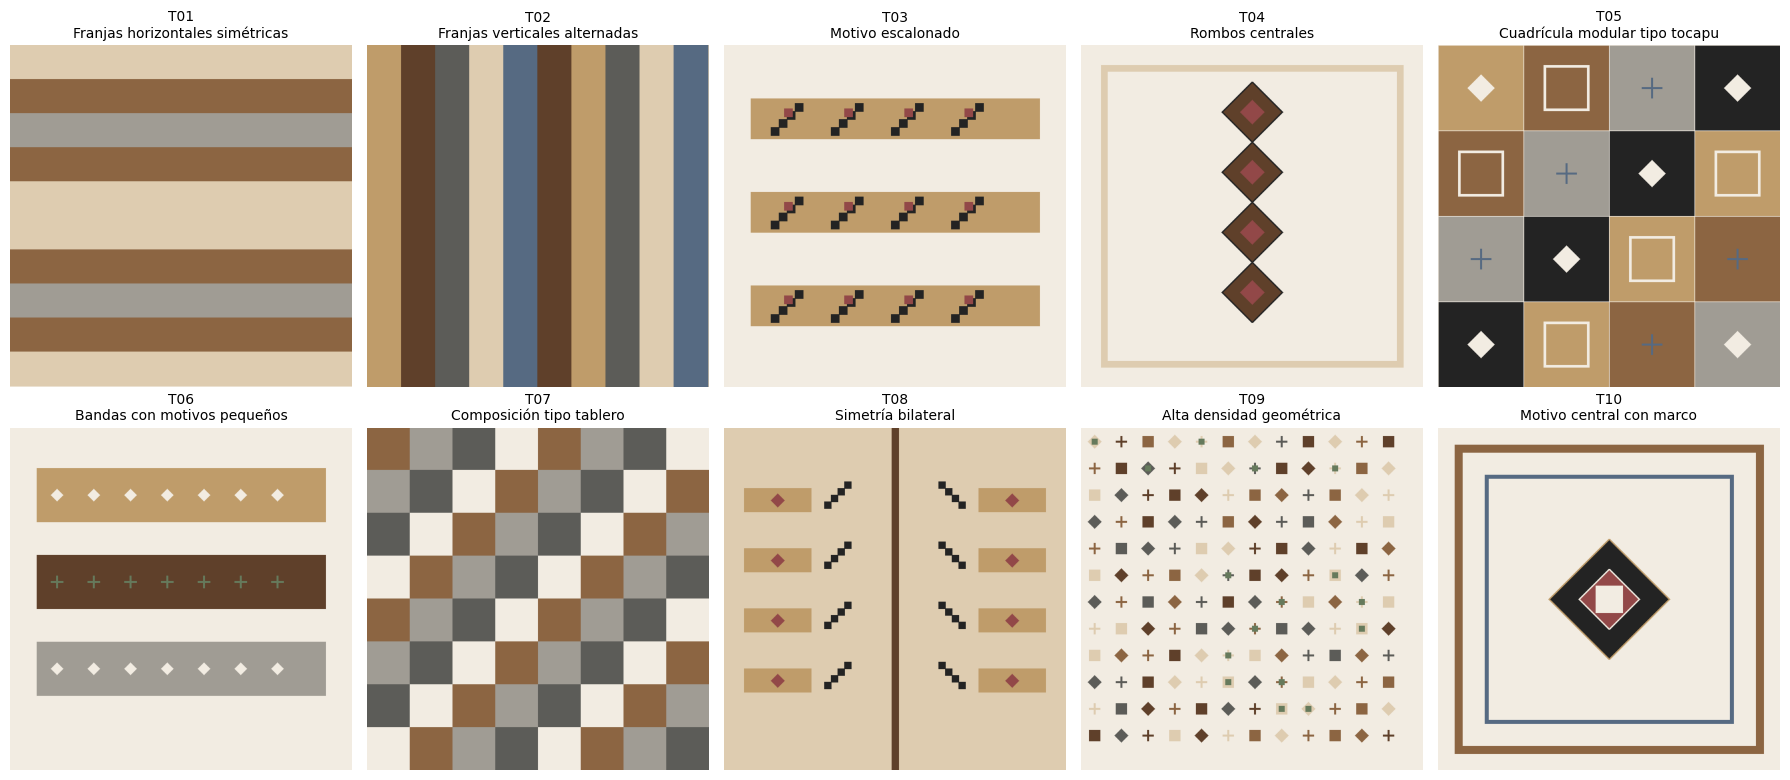

Grilla guardada en: /content/textiles_andinos_sinteticos/outputs/muestra_textiles_sinteticos.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for ax, row in zip(axes, df.itertuples()):
    img = Image.open(row.file_path)
    ax.imshow(img)
    ax.set_title(f"{row.image_id}\n{row.nombre}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
grid_path = os.path.join(OUT_DIR, "muestra_textiles_sinteticos.png")
plt.savefig(grid_path, dpi=200, bbox_inches="tight")
plt.show()

print("Grilla guardada en:", grid_path)

#Construcción del conjunto textual

Aquí incluimos las 10 descripciones correctas y agregamos 5 distractoras, para que el retrieval no sea demasiado trivial.

In [ ]:
correct_texts = df["descripcion_correcta"].tolist()

distractor_texts = [
    "Textil sintético con composición radial y círculos concéntricos.",
    "Diseño visual con figuras animales estilizadas y distribución dispersa.",
    "Patrón textil con diagonales cruzadas y fuerte contraste cromático.",
    "Composición de textura orgánica irregular sin repetición geométrica dominante.",
    "Textil sintético con bandas curvas ondulantes y organización fluida."
]

candidate_texts = correct_texts + distractor_texts

text_df = pd.DataFrame({
    "text_id": [f"TXT_{i+1:02d}" for i in range(len(candidate_texts))],
    "texto": candidate_texts
})

text_df

,text_id,texto
0,TXT_01,Textil andino sintético con franjas horizontal...
1,TXT_02,Textil andino sintético con franjas verticales...
2,TXT_03,Textil andino sintético con motivo geométrico ...
3,TXT_04,Textil andino sintético con rombos centrales r...
4,TXT_05,Textil andino sintético con composición modula...
5,TXT_06,Textil andino sintético con bandas decorativas...
6,TXT_07,Textil andino sintético con bloques cuadrados ...
7,TXT_08,Textil andino sintético con composición bilate...
8,TXT_09,Textil andino sintético de alta densidad geomé...
9,TXT_10,Textil andino sintético con motivo geométrico ...


#Guardado del metadata del experimento

In [ ]:
metadata_path = os.path.join(BASE_DIR, "metadata_textiles.csv")
df.to_csv(metadata_path, index=False)

candidate_texts_path = os.path.join(BASE_DIR, "candidate_texts.csv")
text_df.to_csv(candidate_texts_path, index=False)

print("Metadata de imágenes guardado en:", metadata_path)
print("Textos candidatos guardados en:", candidate_texts_path)

Metadata de imágenes guardado en: /content/textiles_andinos_sinteticos/metadata_textiles.csv
Textos candidatos guardados en: /content/textiles_andinos_sinteticos/candidate_texts.csv


#Carga de OpenCLIP

In [ ]:
# ============================================================
# Línea base multimodal con OpenCLIP
# ============================================================

MODEL_NAME = "ViT-B-32"
PRETRAINED = "laion2b_s34b_b79k"

model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model = model.to(DEVICE)
model.eval()

print(f"Modelo cargado correctamente: {MODEL_NAME} | {PRETRAINED}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Modelo cargado correctamente: ViT-B-32 | laion2b_s34b_b79k


#Obtención de embeddings de imágenes

In [ ]:
image_embeddings = []

with torch.no_grad():
    for row in df.itertuples():
        img = Image.open(row.file_path).convert("RGB")
        image_tensor = preprocess(img).unsqueeze(0).to(DEVICE)

        img_feat = model.encode_image(image_tensor)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        image_embeddings.append(img_feat.cpu().numpy()[0])

image_embeddings = np.vstack(image_embeddings)
print("Shape embeddings de imagen:", image_embeddings.shape)

Shape embeddings de imagen: (10, 512)


#Obtención de embeddings de texto

In [ ]:
with torch.no_grad():
    text_tokens = tokenizer(candidate_texts).to(DEVICE)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

text_embeddings = text_features.cpu().numpy()
print("Shape embeddings de texto:", text_embeddings.shape)

Shape embeddings de texto: (15, 512)


#Matriz de similitud imagen-texto

In [ ]:
sim_matrix = cosine_similarity(image_embeddings, text_embeddings)

sim_df = pd.DataFrame(
    sim_matrix,
    index=df["image_id"].tolist(),
    columns=text_df["text_id"].tolist()
)

sim_df.head()

,TXT_01,TXT_02,TXT_03,TXT_04,TXT_05,TXT_06,TXT_07,TXT_08,TXT_09,TXT_10,TXT_11,TXT_12,TXT_13,TXT_14,TXT_15
T01,0.243603,0.198891,0.222105,0.153888,0.199909,0.208128,0.224426,0.204945,0.168486,0.220798,0.199560,0.118020,0.230369,0.187703,0.210666
T02,0.218072,0.197156,0.229397,0.129596,0.186151,0.192159,0.213604,0.194632,0.160691,0.215024,0.200144,0.110721,0.212315,0.187886,0.167451
T03,0.200451,0.173062,0.217545,0.190505,0.193819,0.229038,0.215884,0.197651,0.195038,0.223129,0.196802,0.175938,0.249296,0.200427,0.211755
T04,0.175667,0.176499,0.227376,0.200996,0.183356,0.216443,0.198320,0.183983,0.216066,0.222608,0.180695,0.142907,0.253356,0.207090,0.152811
T05,0.199171,0.181313,0.273621,0.207376,0.220503,0.231196,0.258517,0.230988,0.225998,0.258014,0.216680,0.128195,0.221657,0.207108,0.148962


#Heatmap de similitud

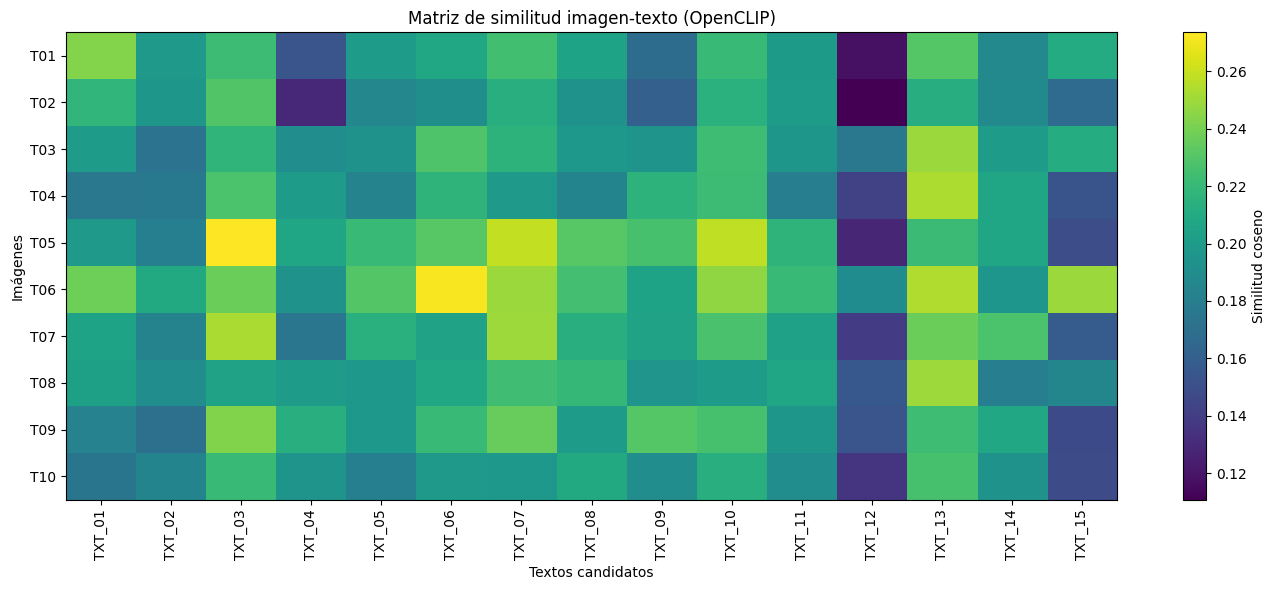

Heatmap guardado en: /content/textiles_andinos_sinteticos/outputs/heatmap_similitud.png


In [ ]:
plt.figure(figsize=(14, 6))
plt.imshow(sim_matrix, aspect="auto")
plt.colorbar(label="Similitud coseno")
plt.xticks(ticks=np.arange(len(candidate_texts)), labels=text_df["text_id"], rotation=90)
plt.yticks(ticks=np.arange(len(df)), labels=df["image_id"])
plt.title("Matriz de similitud imagen-texto (OpenCLIP)")
plt.xlabel("Textos candidatos")
plt.ylabel("Imágenes")
plt.tight_layout()

heatmap_path = os.path.join(OUT_DIR, "heatmap_similitud.png")
plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print("Heatmap guardado en:", heatmap_path)

#Evaluación imagen → texto (Top-K)

In [ ]:
# ============================================================
# Para cada imagen, la descripción correcta está en la misma
# posición 0..9 de correct_texts.
# ============================================================

results_i2t = []

for i, row in enumerate(df.itertuples()):
    scores = sim_matrix[i]
    ranked_idx = np.argsort(scores)[::-1]  # descendente

    top1_idx = ranked_idx[0]
    top3_idx = ranked_idx[:3]
    top5_idx = ranked_idx[:5]

    correct_idx = i  # porque las primeras 10 descripciones son las correctas en orden

    result = {
        "image_id": row.image_id,
        "descripcion_correcta": row.descripcion_correcta,
        "top1_texto": candidate_texts[top1_idx],
        "top1_text_id": text_df.iloc[top1_idx]["text_id"],
        "correct_in_top1": int(correct_idx in ranked_idx[:1]),
        "correct_in_top3": int(correct_idx in top3_idx),
        "correct_in_top5": int(correct_idx in top5_idx),
    }
    results_i2t.append(result)

results_i2t_df = pd.DataFrame(results_i2t)
results_i2t_df

,image_id,descripcion_correcta,top1_texto,top1_text_id,correct_in_top1,correct_in_top3,correct_in_top5
0,T01,Textil andino sintético con franjas horizontal...,Textil andino sintético con franjas horizontal...,TXT_01,1,1,1
1,T02,Textil andino sintético con franjas verticales...,Textil andino sintético con motivo geométrico ...,TXT_03,0,0,0
2,T03,Textil andino sintético con motivo geométrico ...,Patrón textil con diagonales cruzadas y fuerte...,TXT_13,0,0,1
3,T04,Textil andino sintético con rombos centrales r...,Patrón textil con diagonales cruzadas y fuerte...,TXT_13,0,0,0
4,T05,Textil andino sintético con composición modula...,Textil andino sintético con motivo geométrico ...,TXT_03,0,0,0
5,T06,Textil andino sintético con bandas decorativas...,Textil andino sintético con bandas decorativas...,TXT_06,1,1,1
6,T07,Textil andino sintético con bloques cuadrados ...,Textil andino sintético con motivo geométrico ...,TXT_03,0,1,1
7,T08,Textil andino sintético con composición bilate...,Patrón textil con diagonales cruzadas y fuerte...,TXT_13,0,1,1
8,T09,Textil andino sintético de alta densidad geomé...,Textil andino sintético con motivo geométrico ...,TXT_03,0,1,1
9,T10,Textil andino sintético con motivo geométrico ...,Patrón textil con diagonales cruzadas y fuerte...,TXT_13,0,1,1


#Métricas Recall@K para imagen → texto

In [ ]:
recall_at_1 = results_i2t_df["correct_in_top1"].mean()
recall_at_3 = results_i2t_df["correct_in_top3"].mean()
recall_at_5 = results_i2t_df["correct_in_top5"].mean()

metrics_i2t = pd.DataFrame({
    "Métrica": ["Recall@1", "Recall@3", "Recall@5"],
    "Valor": [recall_at_1, recall_at_3, recall_at_5]
})

metrics_i2t

,Métrica,Valor
0,Recall@1,0.2
1,Recall@3,0.6
2,Recall@5,0.7


#Evaluación texto → imagen (solo para las 10 descripciones correctas)

In [ ]:
# Tomamos solo los primeros 10 textos correctos
sim_matrix_t2i = sim_matrix[:, :10].T  # shape: (10 textos correctos, 10 imágenes)

results_t2i = []

for i in range(10):
    scores = sim_matrix_t2i[i]
    ranked_idx = np.argsort(scores)[::-1]

    top1_idx = ranked_idx[0]
    top3_idx = ranked_idx[:3]
    top5_idx = ranked_idx[:5]

    correct_idx = i

    result = {
        "text_id": text_df.iloc[i]["text_id"],
        "texto": candidate_texts[i],
        "top1_image_id": df.iloc[top1_idx]["image_id"],
        "correct_in_top1": int(correct_idx in ranked_idx[:1]),
        "correct_in_top3": int(correct_idx in top3_idx),
        "correct_in_top5": int(correct_idx in top5_idx),
    }
    results_t2i.append(result)

results_t2i_df = pd.DataFrame(results_t2i)
results_t2i_df

,text_id,texto,top1_image_id,correct_in_top1,correct_in_top3,correct_in_top5
0,TXT_01,Textil andino sintético con franjas horizontal...,T01,1,1,1
1,TXT_02,Textil andino sintético con franjas verticales...,T06,0,1,1
2,TXT_03,Textil andino sintético con motivo geométrico ...,T05,0,0,0
3,TXT_04,Textil andino sintético con rombos centrales r...,T09,0,1,1
4,TXT_05,Textil andino sintético con composición modula...,T06,0,1,1
5,TXT_06,Textil andino sintético con bandas decorativas...,T06,1,1,1
6,TXT_07,Textil andino sintético con bloques cuadrados ...,T05,0,1,1
7,TXT_08,Textil andino sintético con composición bilate...,T05,0,1,1
8,TXT_09,Textil andino sintético de alta densidad geomé...,T09,1,1,1
9,TXT_10,Textil andino sintético con motivo geométrico ...,T05,0,0,0


#Métricas Recall@K para texto → imagen

In [ ]:
recall_t2i_at_1 = results_t2i_df["correct_in_top1"].mean()
recall_t2i_at_3 = results_t2i_df["correct_in_top3"].mean()
recall_t2i_at_5 = results_t2i_df["correct_in_top5"].mean()

metrics_t2i = pd.DataFrame({
    "Métrica": ["Recall@1", "Recall@3", "Recall@5"],
    "Valor": [recall_t2i_at_1, recall_t2i_at_3, recall_t2i_at_5]
})

metrics_t2i

,Métrica,Valor
0,Recall@1,0.3
1,Recall@3,0.8
2,Recall@5,0.8


#Visualización cualitativa de resultados

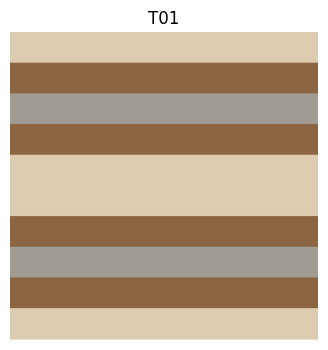

Descripción correcta:
 - Textil andino sintético con franjas horizontales repetidas y organización simétrica del color.

Top-3 textos recuperados:
 1. Textil andino sintético con franjas horizontales repetidas y organización simétrica del color.
 2. Patrón textil con diagonales cruzadas y fuerte contraste cromático.
 3. Textil andino sintético con bloques cuadrados alternados en composición regular tipo tablero.
--------------------------------------------------------------------------------


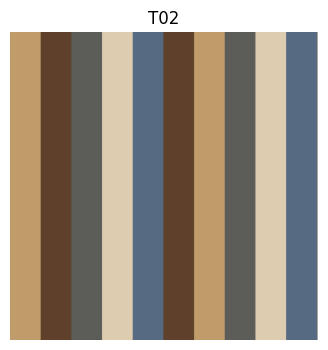

Descripción correcta:
 - Textil andino sintético con franjas verticales alternadas y estructura visual ordenada.

Top-3 textos recuperados:
 1. Textil andino sintético con motivo geométrico escalonado repetido en composición regular.
 2. Textil andino sintético con franjas horizontales repetidas y organización simétrica del color.
 3. Textil andino sintético con motivo geométrico central enmarcado por bandas decorativas.
--------------------------------------------------------------------------------


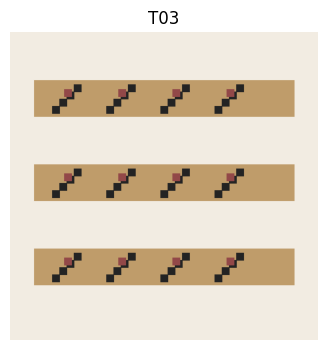

Descripción correcta:
 - Textil andino sintético con motivo geométrico escalonado repetido en composición regular.

Top-3 textos recuperados:
 1. Patrón textil con diagonales cruzadas y fuerte contraste cromático.
 2. Textil andino sintético con bandas decorativas y pequeños motivos geométricos repetidos.
 3. Textil andino sintético con motivo geométrico central enmarcado por bandas decorativas.
--------------------------------------------------------------------------------


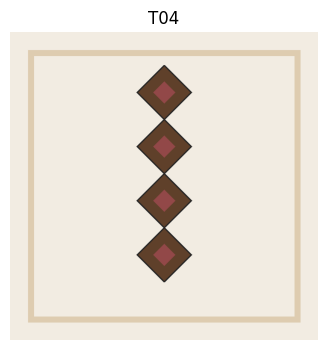

Descripción correcta:
 - Textil andino sintético con rombos centrales repetidos y simetría axial.

Top-3 textos recuperados:
 1. Patrón textil con diagonales cruzadas y fuerte contraste cromático.
 2. Textil andino sintético con motivo geométrico escalonado repetido en composición regular.
 3. Textil andino sintético con motivo geométrico central enmarcado por bandas decorativas.
--------------------------------------------------------------------------------


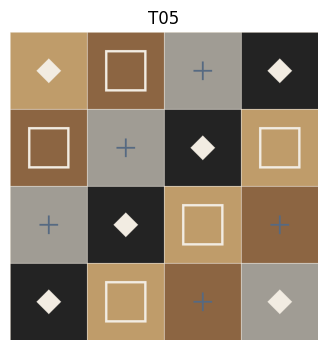

Descripción correcta:
 - Textil andino sintético con composición modular en cuadrícula, inspirada en patrones tipo tocapu.

Top-3 textos recuperados:
 1. Textil andino sintético con motivo geométrico escalonado repetido en composición regular.
 2. Textil andino sintético con bloques cuadrados alternados en composición regular tipo tablero.
 3. Textil andino sintético con motivo geométrico central enmarcado por bandas decorativas.
--------------------------------------------------------------------------------


In [ ]:
def mostrar_resultados_cualitativos(n=5):
    sample_rows = results_i2t_df.head(n)

    for row in sample_rows.itertuples():
        img_path = df[df["image_id"] == row.image_id]["file_path"].values[0]
        img = Image.open(img_path)

        # top 3 textos
        i = df.index[df["image_id"] == row.image_id][0]
        ranked_idx = np.argsort(sim_matrix[i])[::-1][:3]
        top_texts = [candidate_texts[idx] for idx in ranked_idx]

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{row.image_id}")
        plt.show()

        print("Descripción correcta:")
        print(" -", row.descripcion_correcta)
        print("\nTop-3 textos recuperados:")
        for j, txt in enumerate(top_texts, 1):
            print(f" {j}. {txt}")
        print("-" * 80)

mostrar_resultados_cualitativos(n=5)

#Resumen de resultados

In [ ]:
print("===================================================")
print("RESUMEN DE RESULTADOS")
print("===================================================")

print("\nRecuperación imagen -> texto")
display(metrics_i2t)

print("\nRecuperación texto -> imagen")
display(metrics_t2i)

RESUMEN DE RESULTADOS

Recuperación imagen -> texto


,Métrica,Valor
0,Recall@1,0.2
1,Recall@3,0.6
2,Recall@5,0.7



Recuperación texto -> imagen


,Métrica,Valor
0,Recall@1,0.3
1,Recall@3,0.8
2,Recall@5,0.8


#Exportación de resultados

In [ ]:
results_i2t_path = os.path.join(OUT_DIR, "resultados_imagen_a_texto.csv")
results_t2i_path = os.path.join(OUT_DIR, "resultados_texto_a_imagen.csv")
metrics_i2t_path = os.path.join(OUT_DIR, "metricas_imagen_a_texto.csv")
metrics_t2i_path = os.path.join(OUT_DIR, "metricas_texto_a_imagen.csv")
sim_matrix_path = os.path.join(OUT_DIR, "matriz_similitud.csv")

results_i2t_df.to_csv(results_i2t_path, index=False)
results_t2i_df.to_csv(results_t2i_path, index=False)
metrics_i2t.to_csv(metrics_i2t_path, index=False)
metrics_t2i.to_csv(metrics_t2i_path, index=False)
sim_df.to_csv(sim_matrix_path)

print("Archivos exportados:")
print(" -", results_i2t_path)
print(" -", results_t2i_path)
print(" -", metrics_i2t_path)
print(" -", metrics_t2i_path)
print(" -", sim_matrix_path)

Archivos exportados:
 - /content/textiles_andinos_sinteticos/outputs/resultados_imagen_a_texto.csv
 - /content/textiles_andinos_sinteticos/outputs/resultados_texto_a_imagen.csv
 - /content/textiles_andinos_sinteticos/outputs/metricas_imagen_a_texto.csv
 - /content/textiles_andinos_sinteticos/outputs/metricas_texto_a_imagen.csv
 - /content/textiles_andinos_sinteticos/outputs/matriz_similitud.csv


#Interpretación metodológica:

1. El experimento construyó un conjunto sintético controlado de 10 imágenes
   inspiradas en rasgos visuales frecuentes de textiles andinos.

2. A partir de OpenCLIP, se obtuvieron embeddings compartidos para imágenes y textos,
   permitiendo medir similitud semántica y evaluar tareas de recuperación multimodal.

3. Este mini-experimento constituye una línea base reproducible de alineamiento
   imagen-texto, útil para ilustrar cómo funciona el retrieval multimodal.

4. Sin embargo, un buen resultado de similitud NO implica interpretación cultural
   profunda. El modelo puede asociar patrones visuales y textos, pero eso no equivale
   a comprender plenamente el significado histórico, técnico o simbólico del textil.

5. En este punto aparece la relevancia de ALBEF: si el alineamiento inicial resulta
   útil, una arquitectura que alinee primero y luego fusione puede capturar relaciones
   más finas entre patrones visuales y lenguaje descriptivo.



#Conexión con ALBEF:

Este notebook reproduce la lógica básica de alineamiento imagen-texto mediante
embeddings compartidos, similar al enfoque contrastivo de CLIP/OpenCLIP.
Desde esa perspectiva, funciona como una línea base reproducible.

La relevancia de ALBEF es que propone un paso adicional:
1. alinear primero imagen y texto (como aquí),
2. y luego fusionarlos mediante atención crossmodal.

Por ello, este experimento puede interpretarse como una evidencia inicial
que justifica por qué 'align before fuse' puede ser una estrategia pertinente
para problemas más complejos, como el análisis computacional de textiles andinos.
